<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Detection/HC_Model_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook applies the Characteristic Point Detector (model_v4.keras), trained on the ReBeat database, to the HeartCycle database. We evaluate the detector's robustness against signal variations and changes in hemodynamic parameters. Signal processing steps are preserved to maintain access to the variables used during training.

# Load Data

We load the data from Google Drive.

In [248]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from google.colab import drive

from scipy.signal import butter, filtfilt, savgol_filter, resample
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler  # Z-score scaler

from tensorflow.keras.models import load_model

In [249]:
# mount Google Drive
drive.mount('/content/drive')
dir_path = "/content/drive/MyDrive/TFG/Data_HeartCycle/59146238"

file_path = '/content/drive/MyDrive/TFG/Data_HeartCycle/59146238/59146238_s0000041.mat'
data_hc = sio.loadmat(file_path)
print(data_hc.keys())

header = data_hc['__header__']
#print(header) #b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Thu Mar 12 19:36:31 2009'

version = data_hc['__version__']
#print(version) # 1.0

globals = data_hc['__globals__']
#print(globals) # []

measures = data_hc['measure']
#print(measures)

print(type(measures))        # ndarray
print(measures.shape)       # 30 rows and 5 columns

rows, cols = measures.shape # measures is a 30x5 ndarray
# to see which signals we have
for i in range(rows):
    for j in range(cols):
        try:
            label = measures[i, j]['label'][0, 0]
            print(f"{label} = measures[{i},{j}]")
        except:
            continue

print(measures[1,1]['label'][0]) #ICG

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dict_keys(['__header__', '__version__', '__globals__', 'measure'])
<class 'numpy.ndarray'>
(30, 4)
['Event'] = measures[0,0]
['ECG'] = measures[0,1]
['ECG'] = measures[0,2]
['ECG'] = measures[0,3]
['SPO2'] = measures[1,0]
['IMP'] = measures[1,1]
['PCG'] = measures[1,2]
['ECHO'] = measures[1,3]
['O/C'] = measures[2,0]
['RPEAKS'] = measures[2,1]
['RPEAKS'] = measures[2,2]
['RPEAKS'] = measures[2,3]
['Load'] = measures[3,0]
['AVO'] = measures[3,1]
['AVO'] = measures[3,2]
['AVO'] = measures[3,3]
['HPD'] = measures[4,0]
['PEP'] = measures[4,1]
['PEP'] = measures[4,2]
['PEP'] = measures[4,3]
['DC'] = measures[5,0]
['AVC'] = measures[5,1]
['AVC'] = measures[5,2]
['AVC'] = measures[5,3]
['TFC'] = measures[6,0]
['LVET'] = measures[6,1]
['LVET'] = measures[6,2]
['LVET'] = measures[6,3]
['FC'] = measures[7,0]
['Heather'] = measures[8,0]
['Z<sm>0</sm>'] = measures[9,0]
[

# Signal Preprocessing (ICG, ECG)

## ICG Preprocessing

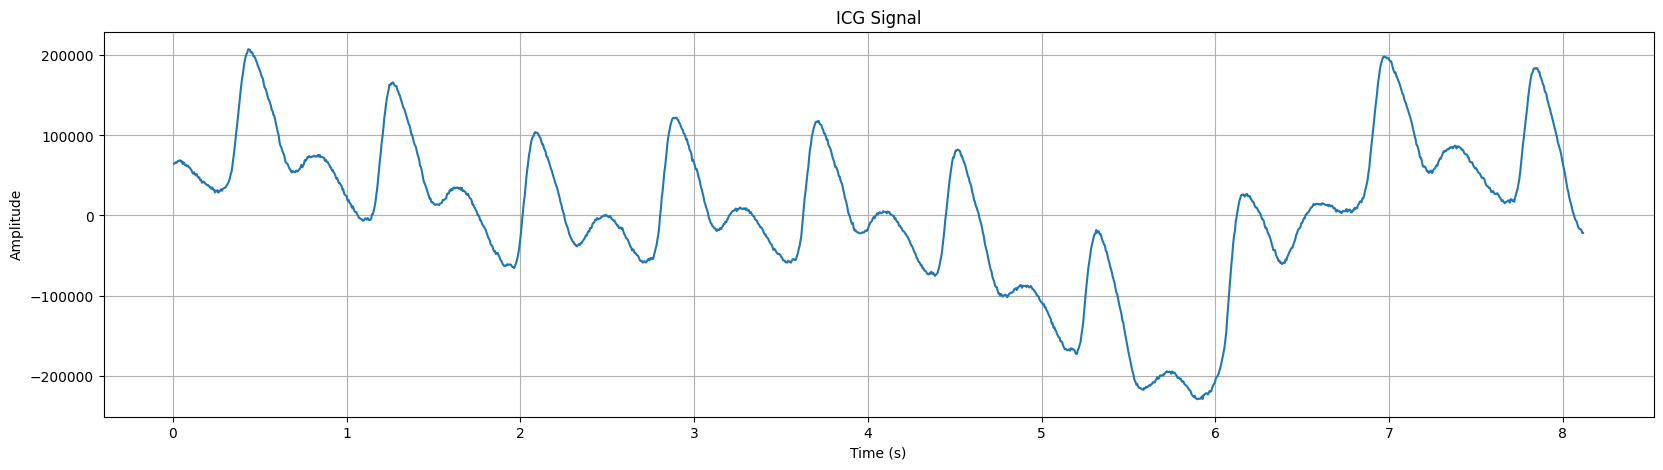

In [250]:
icg = measures[1,1] #extract the ICG signal
icg_time = icg['time'][0,0].flatten()
icg_data = icg['data'][0,0].flatten()

plt.figure(figsize=(20, 5))
plt.plot(icg_time, icg_data)
plt.title('ICG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Band pass filtering

In [251]:
dt = np.mean(np.diff(icg_time))      #time step, we calculate the average interval between consecutive time samples
fs = 1 / dt                          #sampling frequency
print(fs) #198.45387059502093

199.13263157894815


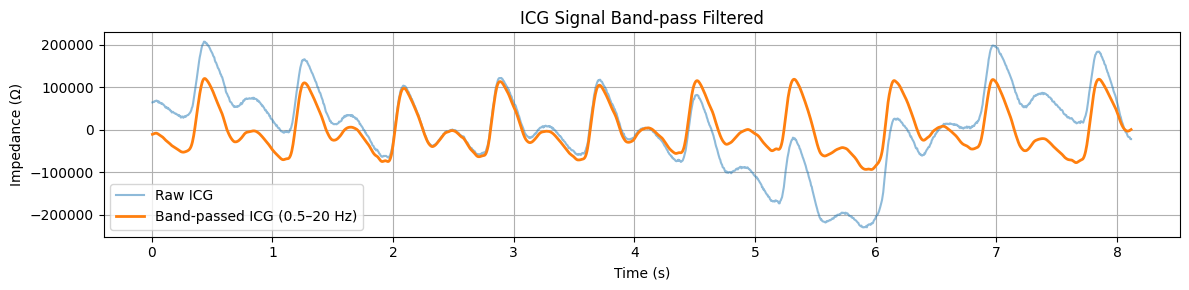

In [252]:
def bandpass(signal, fs, lowcut, highcut, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)
icg_bandpassed = bandpass(icg_data, fs,0.5,20)

plt.figure(figsize=(12, 3))
plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.5)
plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG (0.5–20 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Impedance (Ω)')
plt.title('ICG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Baseline removal

The Savitzky-Golay filter is a smoothing filter based on local polynomial regression. Instead of simply averaging neighboring points (like a moving average does), SG fits a polynomial curve to a small window of the data, and replaces the center point with the value predicted by that polynomial.

We use SG to estimate the low-frequency trend (baseline), and then subtract it. Here, SG is not used to smooth the signal but to isolate the low-frequency component (like respiration or motion drift).

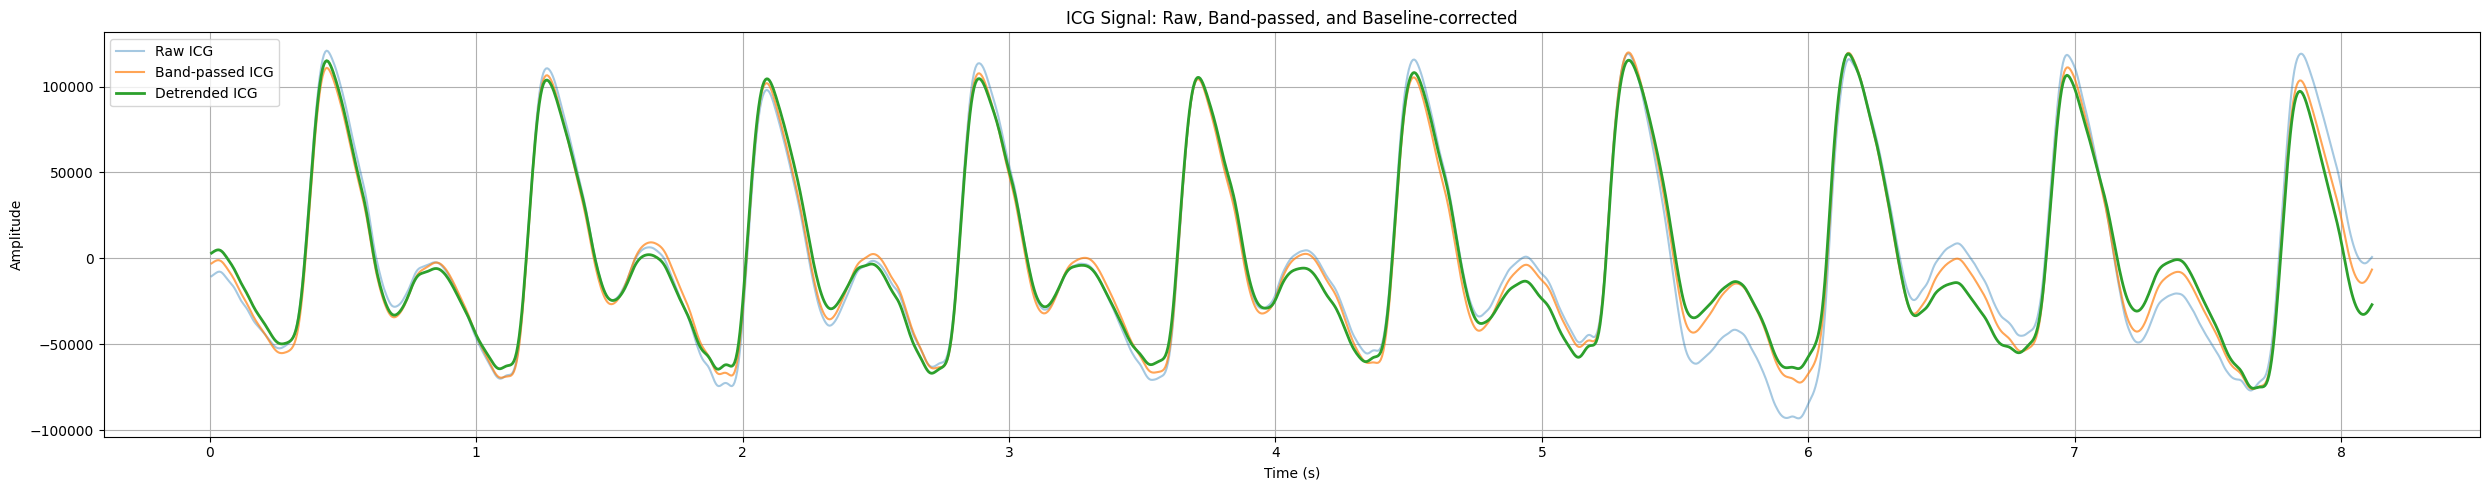

Text(0.5, 1.0, 'Preprocessed ICG Signal')

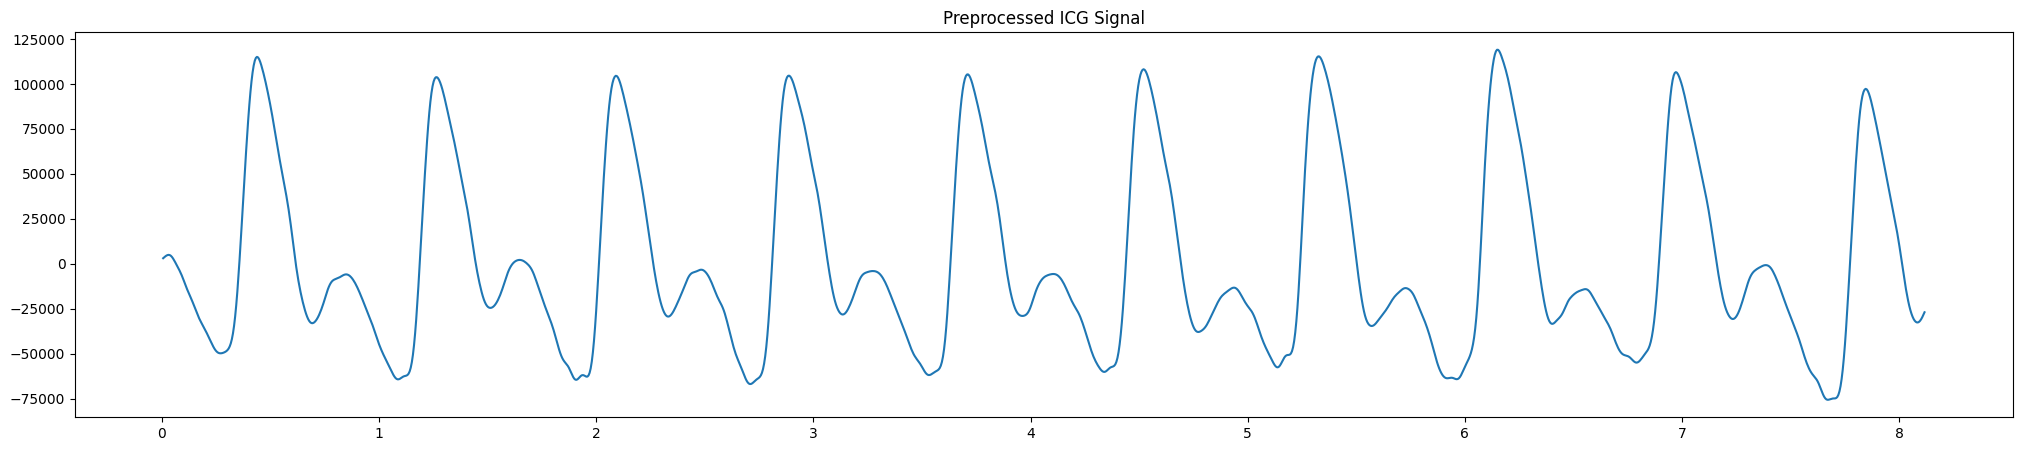

In [253]:
def preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2):
    # Bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)

    # Baseline estimation using SG and subtraction
    baseline = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)
    icg_detrended = icg_bandpassed - baseline

    # Plot
    plt.figure(figsize=(25, 5))
    plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.4)
    plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG', alpha=0.7)
    plt.plot(icg_time, icg_detrended, label='Detrended ICG', linewidth=2)
    plt.legend()
    plt.title("ICG Signal: Raw, Band-passed, and Baseline-corrected")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return icg_detrended

icg_detrended = preprocess_icg_detrend(icg_bandpassed, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2)
plt.figure(figsize=(25, 5))
plt.plot(icg_time, icg_detrended)
plt.title("Preprocessed ICG Signal")

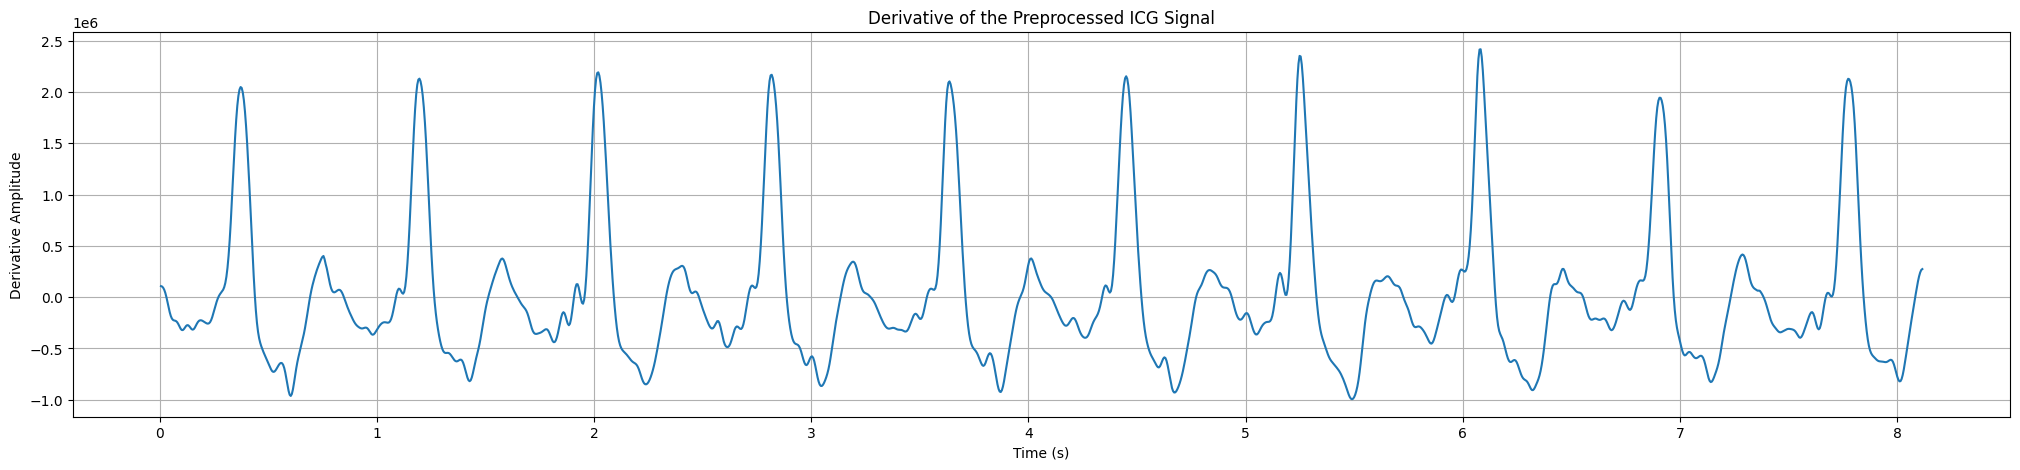

In [254]:
# Calculate the derivative using central difference method
dt = np.mean(np.diff(icg_time))
dz_dt = np.gradient(icg_detrended, dt)

# Plot the derivative
plt.figure(figsize=(25, 5))
plt.plot(icg_time, dz_dt)
plt.title("Derivative of the Preprocessed ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Derivative Amplitude")
plt.grid(True)
plt.show()


Conclusion: We apply band-pass filtering followed by Savitzky-Golay (SG) filtering to detrend the impedance signal. After obtaining the cleaned signal, we compute its derivative to enhance characteristic point detection.

##ECG Preprocessing

We have 4 ECG signals with different sampling frequencies.

Sampling Frequency ECG 1: 199.13 Hz


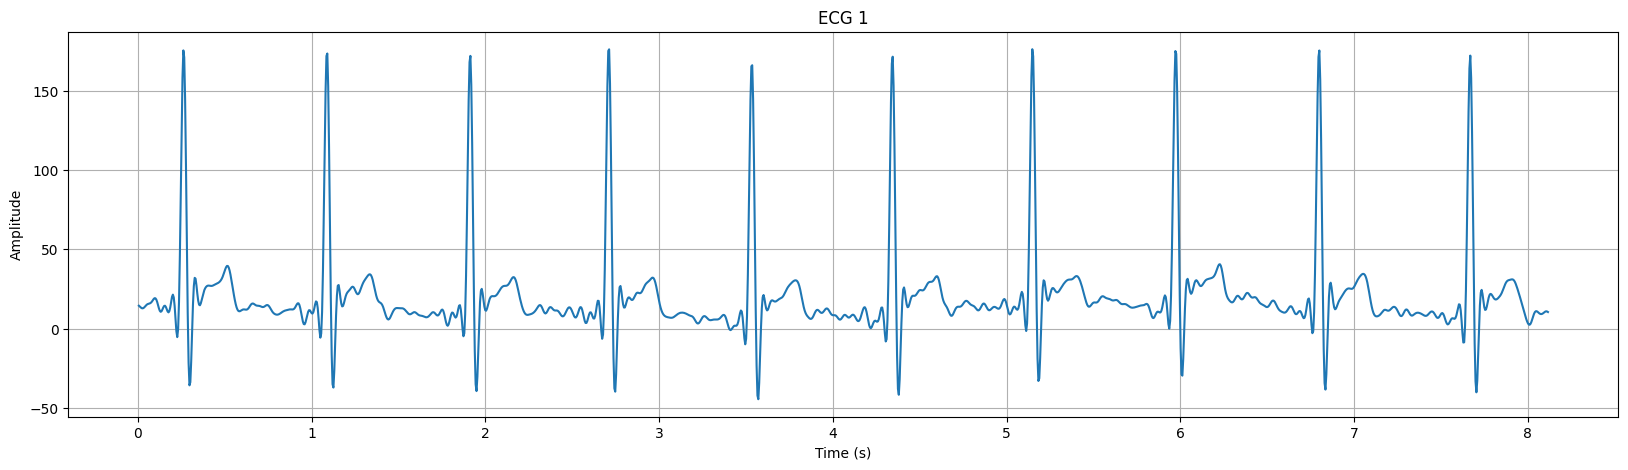

In [255]:
ecg_1 = measures[0, 1]

ecg_1_time = ecg_1['time'][0, 0].flatten()
ecg_1_data = ecg_1['data'][0, 0].flatten()

# Plot ECG 1
plt.figure(figsize=(20, 5))
plt.plot(ecg_1_time, ecg_1_data)
plt.title('ECG 1')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

def get_sampling_frequency(time_array):
    time_diffs = np.diff(time_array)
    avg_time_step = np.mean(time_diffs)
    fs = 1 / avg_time_step
    return fs

fs_1 = get_sampling_frequency(ecg_1_time)

print(f"Sampling Frequency ECG 1: {fs_1:.2f} Hz")

We observe that ECG channel 1 often exhibits baseline drift. To address this, we apply a band-pass filter. The recommended range by the American Heart Association is 0.05 Hz to 150 Hz. However, we encounter a limitation:

ValueError: Digital filter critical frequencies must be 0 < Wn < 1

This error occurs because the high cutoff frequency (150 Hz) exceeds the valid range relative to the Nyquist frequency (nyq = fs_3 / 2). The butter function requires the cutoff frequencies to be normalized between 0 and 1, where 1 corresponds to the Nyquist frequency.


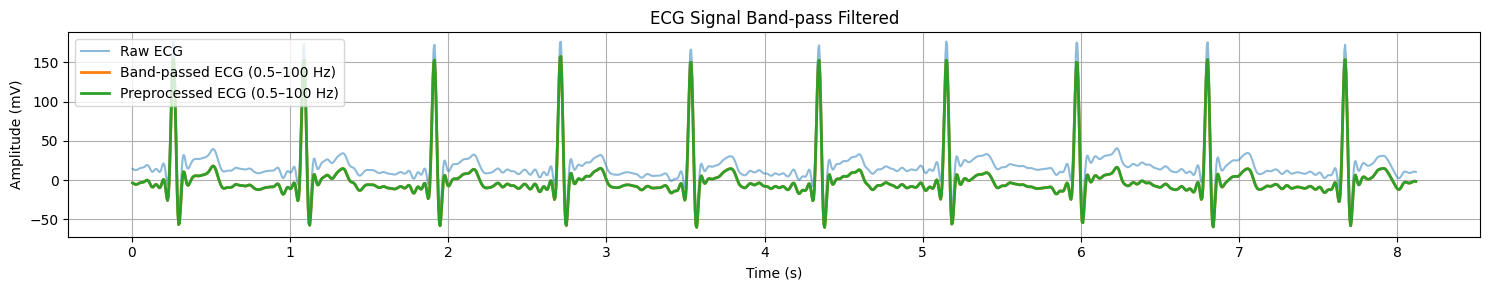

In [256]:
from scipy.signal import iirnotch

def notch_filter(data, fs, freq=50, quality_factor=30):
    b, a = iirnotch(freq, quality_factor, fs)
    return filtfilt(b, a, data)

ecg_1_bandpassed = bandpass(ecg_1_data, fs_1, 0.5,45)
ecg_1_preprocessed = notch_filter(ecg_1_bandpassed, fs_1, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_1_time, ecg_1_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_1_time, ecg_1_bandpassed, label='Band-passed ECG (0.5–100 Hz)', linewidth=2)
plt.plot(ecg_1_time, ecg_1_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We normalize with Z score so we can plot it with ICG.

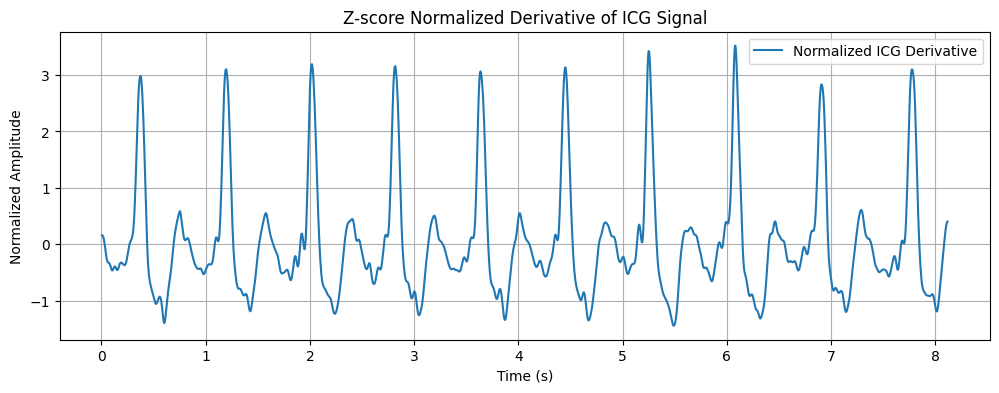

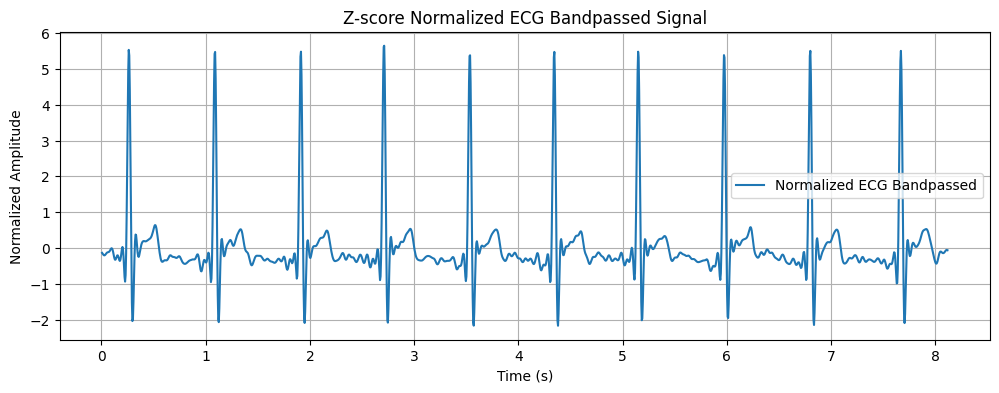

In [257]:
scaler_icg = StandardScaler()
dz_dt_norm = scaler_icg.fit_transform(dz_dt.reshape(-1, 1))

scaler_ecg = StandardScaler()
ecg_1_bandpassed_normalized = scaler_ecg.fit_transform(ecg_1_bandpassed.reshape(-1, 1))

# Plot normalized ICG derivative
plt.figure(figsize=(12, 4))
plt.plot(icg_time, dz_dt_norm, label='Normalized ICG Derivative')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('Z-score Normalized Derivative of ICG Signal')
plt.grid(True)
plt.legend()
plt.show()

# Plot normalized ECG
plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_bandpassed_normalized, label='Normalized ECG Bandpassed')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('Z-score Normalized ECG Bandpassed Signal')
plt.grid(True)
plt.legend()
plt.show()


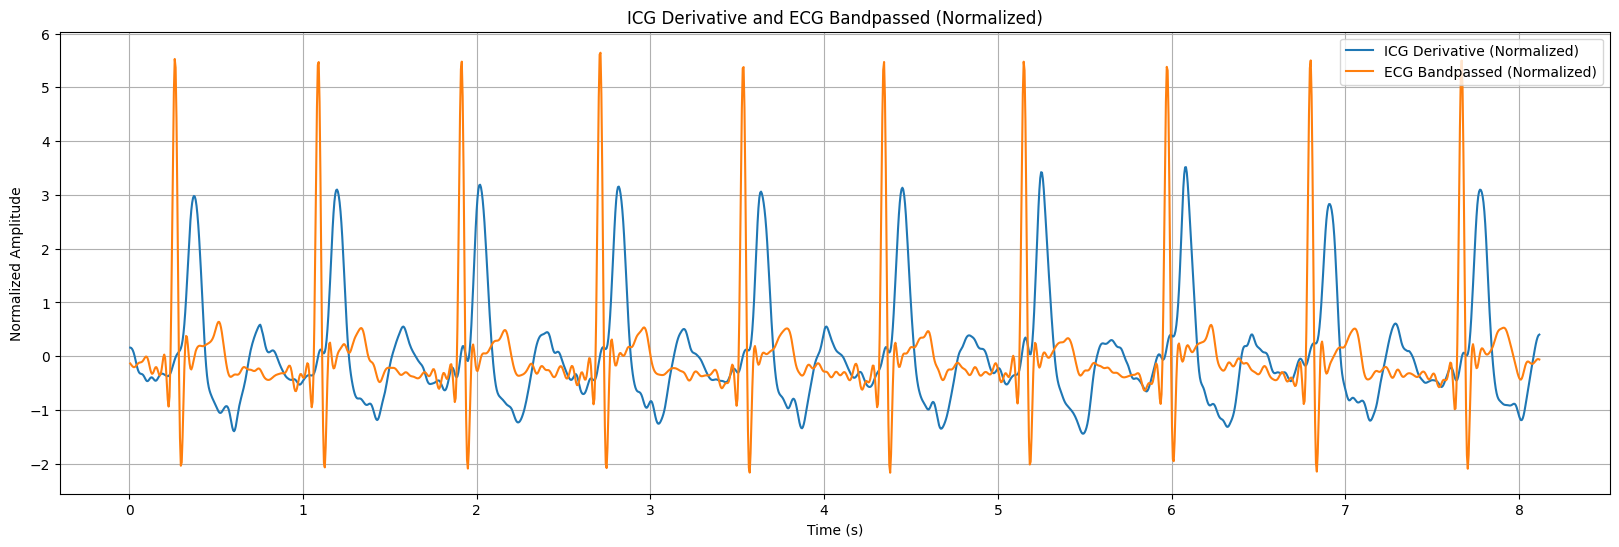

In [258]:
plt.figure(figsize=(20, 6))
plt.plot(icg_time, dz_dt_norm, label='ICG Derivative (Normalized)')
plt.plot(ecg_1_time, ecg_1_bandpassed_normalized, label='ECG Bandpassed (Normalized)')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('ICG Derivative and ECG Bandpassed (Normalized)')
plt.legend()
plt.grid(True)
plt.show()


#ECG R peaks

[0.26227634 1.09086982 1.91444152 2.71290433 3.53647603 4.34498239
 5.14846698 5.97203868 6.80063216 7.66939987]


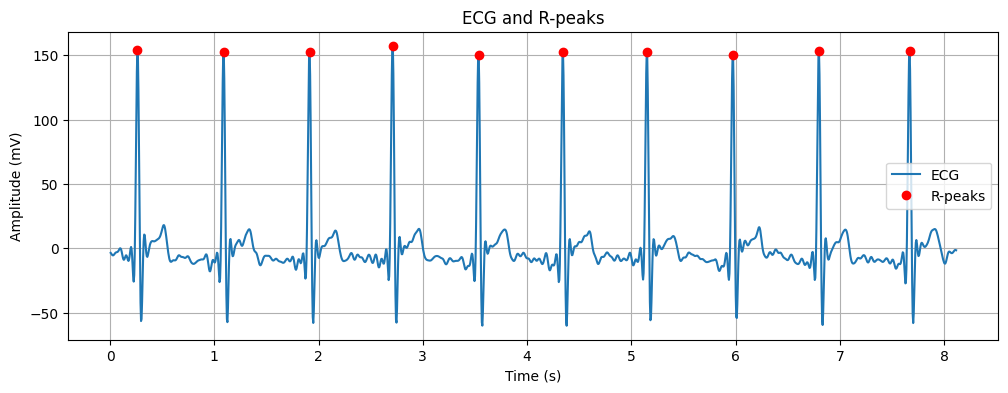

In [259]:
rpeaks = measures[2,1]
rpeaks_time = rpeaks['time'][0,0].flatten()
rpeaks_values = rpeaks['data'][0,0].flatten()

rpeaks_times = np.array(rpeaks_values) # numpy array
print(rpeaks_times)

# find the closest points to the time second
rpeaks_index = np.array([np.argmin(np.abs(ecg_1_time - t)) for t in rpeaks_times])

plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_preprocessed, label='ECG')
plt.plot(ecg_1_time[rpeaks_index], ecg_1_preprocessed[rpeaks_index], 'ro', label='R-peaks') #put the r peaks in red points
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


Normalize ECG and ICG (MinMax)

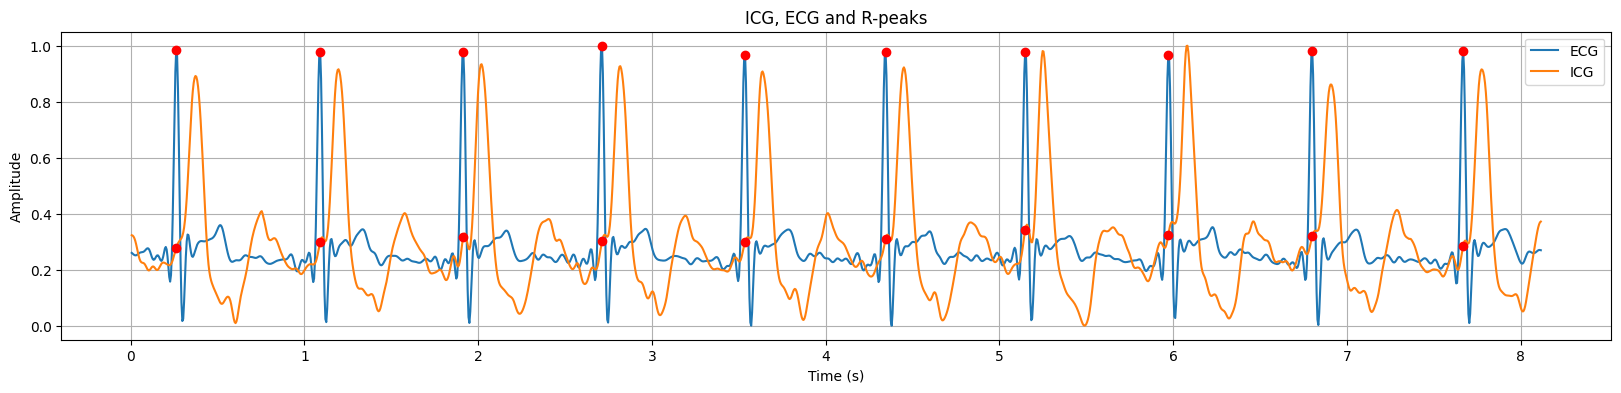

In [260]:
def normalize(signal):
    return (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

ecg_norm = normalize(ecg_1_preprocessed)
icg_norm = normalize(dz_dt)

plt.figure(figsize=(20, 4))
plt.plot(ecg_1_time, ecg_norm, label='ECG')
plt.plot(icg_time, icg_norm, label='ICG')
plt.plot(ecg_1_time[rpeaks_index], ecg_norm[rpeaks_index], 'ro')
plt.plot(icg_time[rpeaks_index], icg_norm[rpeaks_index],'ro')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG, ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


# Model v4 to HeartCycle data

## Model

In [261]:
def segment_icg(signal, r_indices, fs=250, pre_r=0.2, post_r=0.6, n_segments_to_plot=5):
    """
    Extract and normalize segments around R-peaks, plot them (ICG or ECG).

    Parameters:
        signal (array): Full ICG or ECG signal
        r_indices (array): Indices of R-peaks
        fs (int): Sampling frequency (Hz)
        pre_r (float): Time before R in seconds
        post_r (float): Time after R in seconds
        n_segments_to_plot (int): Number of segments to plot

    Returns:
        segments (array): Normalized segments, shape [n_segments, segment_len]
    """
    segment_len = int((pre_r + post_r) * fs)
    offset = int(pre_r * fs)
    segments = []

    for r in r_indices:
        start = r - offset
        end = start + segment_len
        if start >= 0 and end <= len(signal):
            segment = signal[start:end]
            segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)
            segments.append(segment)

    segments = np.array(segments)

    # Plot extracted segments
    plt.figure(figsize=(12, 8))
    for i in range(min(n_segments_to_plot, len(segments))):
        plt.plot(segments[i], label=f'Segment {i+1}')
        plt.scatter(offset, segments[i][offset], color='red', marker='x', s=100, label='R-peak' if i == 0 else "")
    plt.xlabel('Sample')
    plt.ylabel('Amplitude (normalized)')
    plt.title('Extracted Segments Around R-Peaks (R-peak Marked)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return segments


def upsample_segments(segments_old, from_fs=200, to_fs=250):
    """
    Upsample segments only if needed (e.g., HeartCycle from 200 Hz to 250 Hz).

    Parameters:
        segments_old (array): Input segments, shape [n_segments, old_len]
        from_fs (int): Original sampling frequency
        to_fs (int): Target sampling frequency

    Returns:
        segments_upsampled (array): Segments with resampled length
    """
    if from_fs == to_fs:
        return segments_old
    new_len = int(segments_old.shape[1] * to_fs / from_fs)
    return np.array([resample(seg, new_len) for seg in segments_old])


def prepare_icg_model_input(icg_segments_upsampled, ecg_segments_upsampled):
    """
    Stack ICG and ECG into shape [n_segments, 200, 2] for model input.
    Assumes both are already resampled to 200 samples and normalized.

    Returns:
        X_input (array): Input to model, shape [n_segments, 200, 2]
    """
    return np.stack([icg_segments_upsampled, ecg_segments_upsampled], axis=-1)


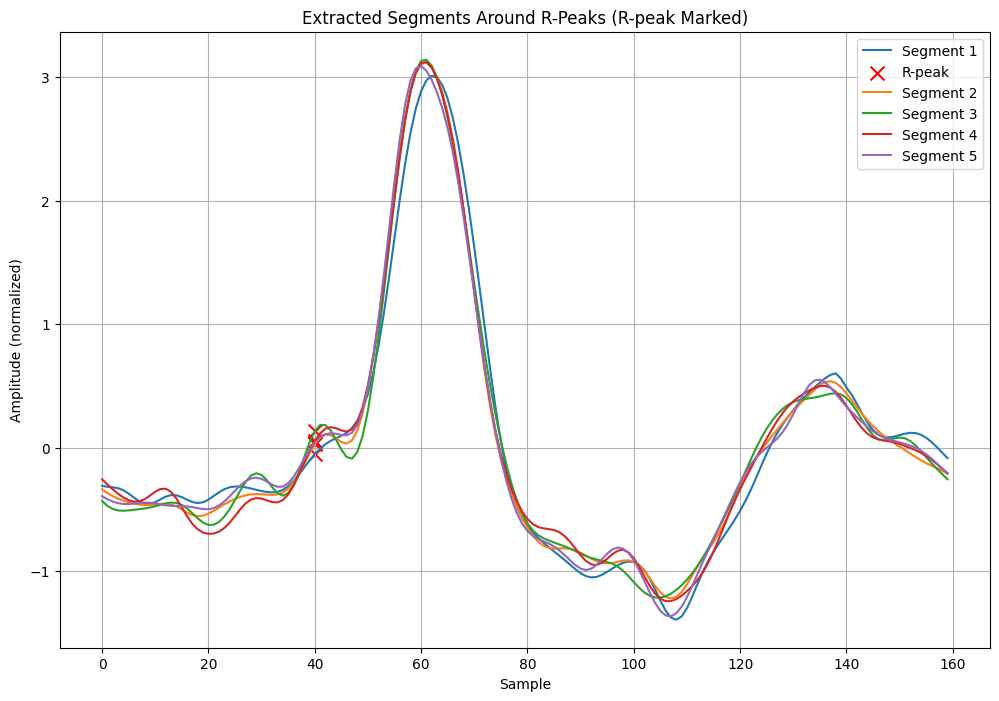

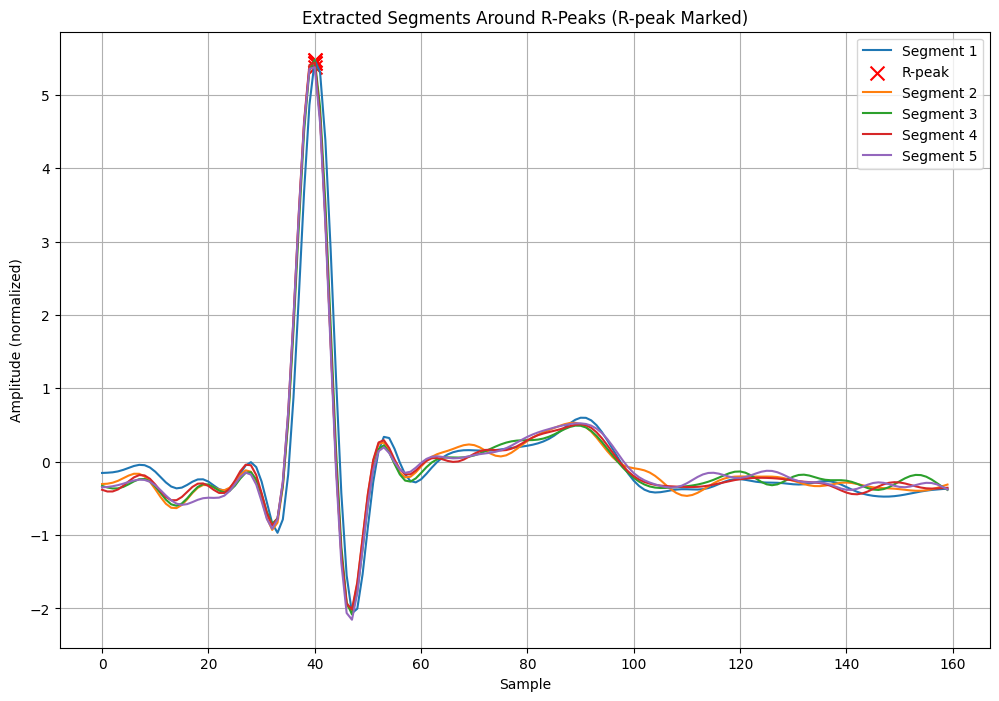

Model input shape: (9, 200, 2)


In [262]:
# Segment ICG and ECG at 200 Hz
icg_segments = segment_icg(dz_dt, rpeaks_index, fs=200)
ecg_segments = segment_icg(ecg_1_preprocessed, rpeaks_index, fs=200)

# Upsample to 250 Hz (from_fs=200 → to_fs=250)
icg_segments_upsampled = upsample_segments(icg_segments, from_fs=200, to_fs=250)
ecg_segments_upsampled = upsample_segments(ecg_segments, from_fs=200, to_fs=250)

# Combine into model input: shape (n_segments, 200, 2)
X_input = prepare_icg_model_input(icg_segments_upsampled, ecg_segments_upsampled)

print("Model input shape:", X_input.shape)  # should be (n_segments, 200, 2)

In [263]:
from google.colab import files
uploaded = files.upload()
model = list(uploaded.keys())[0]

Saving model_v4.keras to model_v4 (6).keras


Model input shape: (9, 200, 2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


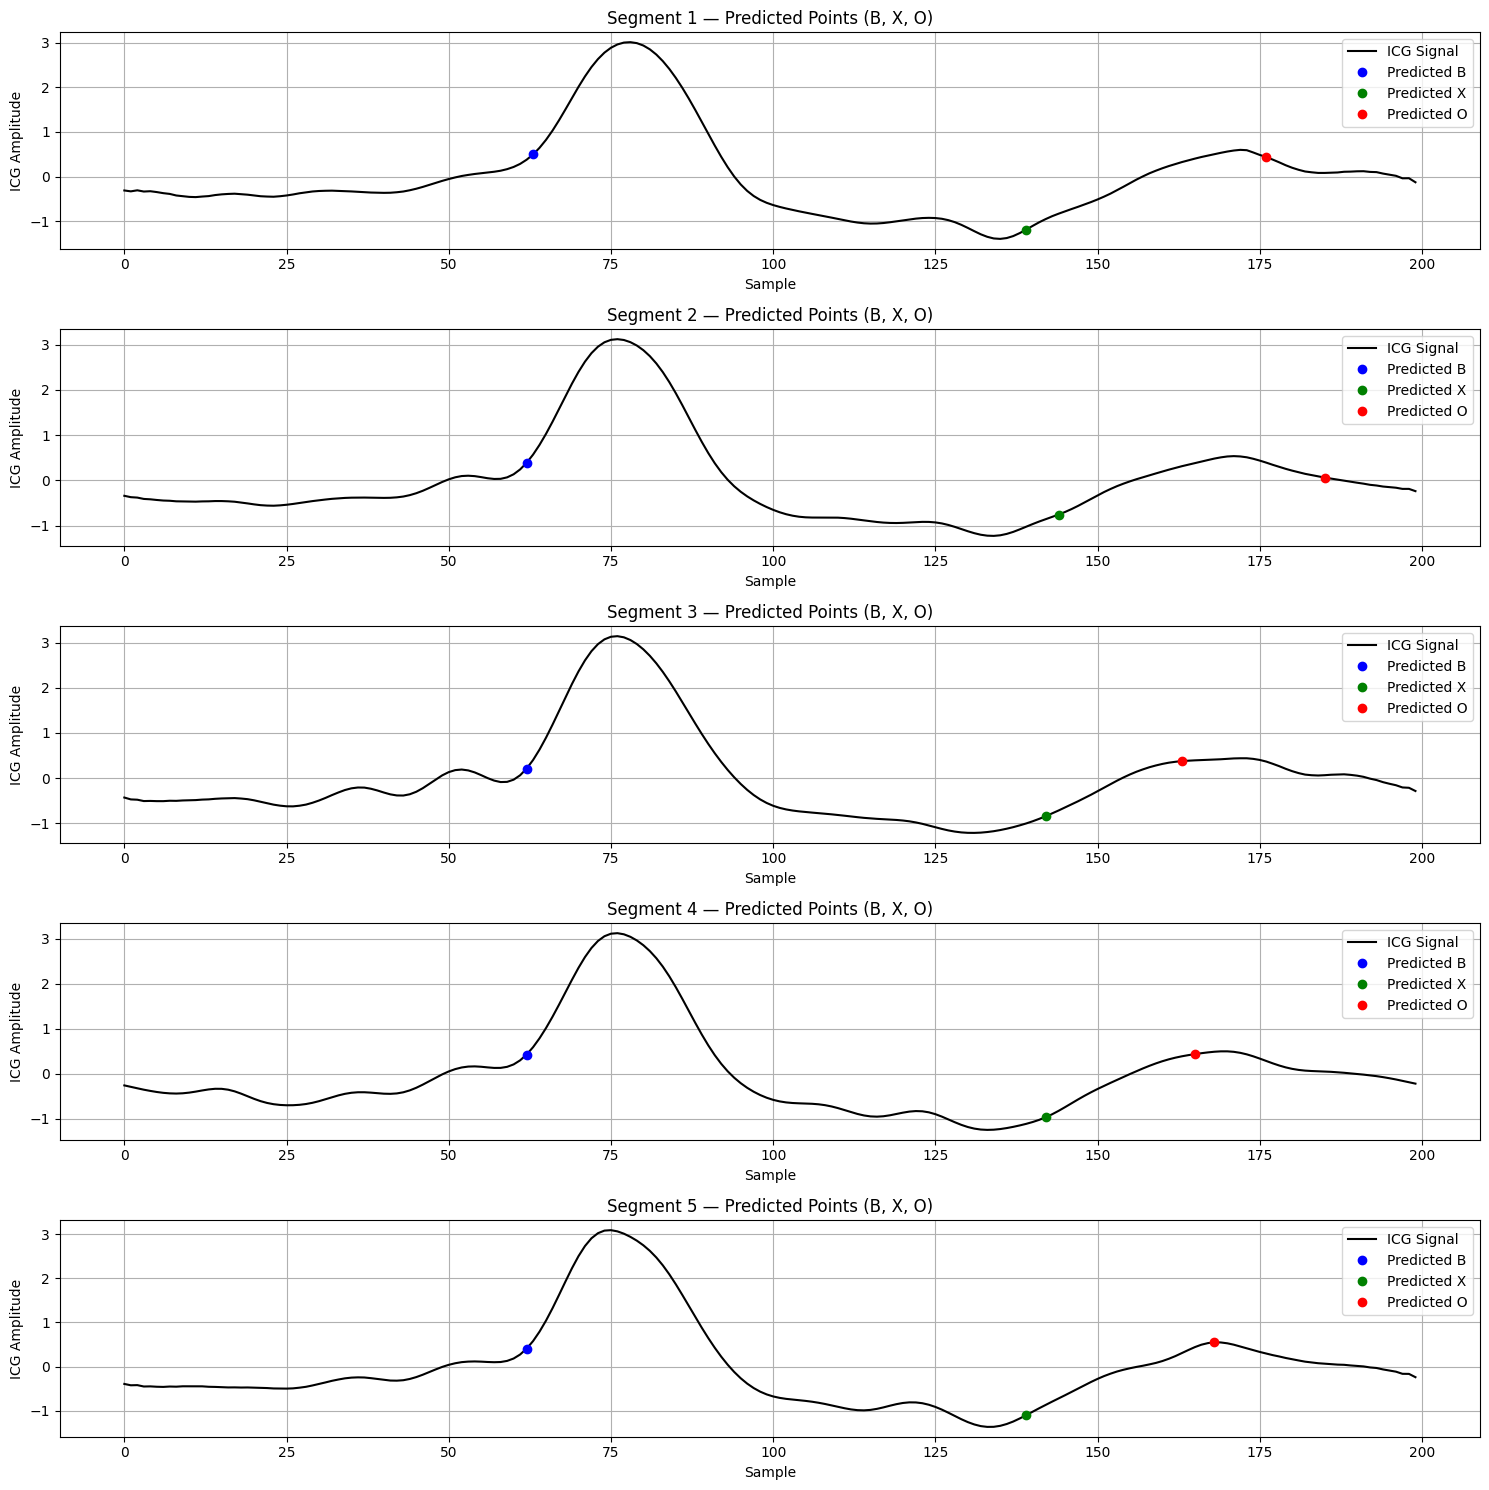

In [264]:
# 1. Create model input
def create_model_input(ecg_segments, icg_segments):
    """
    Combine ECG and ICG segments into shape [n_segments, 200, 2],
    and normalize each channel (ECG, ICG) separately per segment.
    """
    assert ecg_segments.shape == icg_segments.shape, "ECG and ICG segment shapes must match"

    ecg_norm = (ecg_segments - np.mean(ecg_segments, axis=1, keepdims=True)) / (np.std(ecg_segments, axis=1, keepdims=True) + 1e-8)
    icg_norm = (icg_segments - np.mean(icg_segments, axis=1, keepdims=True)) / (np.std(icg_segments, axis=1, keepdims=True) + 1e-8)

    return np.stack([icg_norm, ecg_norm], axis=-1)  # shape: (n_segments, 200, 2)

# 2. Extract predicted B, X, O points
def extract_predicted_points(y_pred):
    """
    Input:
        y_pred: np.array of shape (n_samples, 200, 3) — softmax outputs
    Returns:
        pred_points: np.array of shape (n_samples, 3), time indices of B, X, O
    """
    return np.argmax(y_pred, axis=1)  # shape: (n_samples, 3)

# 3. Plotting function for ICG and predicted points
def plot_icg_with_predicted_points(icg_segments, predicted_points, n_segments_to_plot=5):
    """
    Plots ICG segments and marks predicted B, X, O points.
    """
    labels = ['B', 'X', 'O']
    colors = ['blue', 'green', 'red']

    plt.figure(figsize=(15, n_segments_to_plot * 3))
    for i in range(min(n_segments_to_plot, len(icg_segments))):
        plt.subplot(n_segments_to_plot, 1, i + 1)
        plt.plot(icg_segments[i], label='ICG Signal', color='black')
        for j, label_name in enumerate(labels):
            idx = predicted_points[i, j]
            if 0 <= idx < icg_segments.shape[1]:
                plt.plot(idx, icg_segments[i, idx], 'o', color=colors[j], label=f'Predicted {label_name}')
        plt.title(f'Segment {i+1} — Predicted Points (B, X, O)')
        plt.xlabel('Sample')
        plt.ylabel('ICG Amplitude')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# 4. Prepare model input
X_input = create_model_input(ecg_segments_upsampled, icg_segments_upsampled)
print("Model input shape:", X_input.shape)  # should be (n_segments, 200, 2)

# 5. Load trained model (3-class B/X/O)
predictor = load_model(model, compile=False)

# 6. Predict
y_pred = predictor.predict(X_input)  # shape: (n_segments, 200, 3)
predicted_labels = extract_predicted_points(y_pred)  # shape: (n_segments, 3)

# 7. Plot predictions over ICG
plot_icg_with_predicted_points(X_input[:, :, 0], predicted_labels)  # ICG = channel 0


## Refine predicted points

In [265]:
def refine_predicted_points(X, predicted_points, window=5):
    """
    Refine predicted points by snapping to local minima/maxima in the ICG signal,
    except for the B point which is kept as predicted.

    Inputs:
        X: np.array of shape (n_samples, 200, 2), where X[:,:,0] is ICG
        predicted_points: np.array of shape (n_samples, 3) — B, X, O indices
        window: int — half-window to search around each predicted point

    Returns:
        refined_points: np.array of shape (n_samples, 3) — refined B, X, O indices
    """
    n_samples = X.shape[0]
    refined_points = np.copy(predicted_points)

    for i in range(n_samples):
        icg = X[i, :, 0]  # ICG signal
        for j, label in enumerate(['B', 'X', 'O']):
            if label == 'B':
                continue  # Keep B point as predicted

            pred_idx = predicted_points[i, j]
            start = max(pred_idx - window, 0)
            end = min(pred_idx + window + 1, len(icg))

            segment = icg[start:end]
            if len(segment) == 0:
                continue

            if label == 'X':  # local minimum
                local_idx = np.argmin(segment)
            elif label == 'O':  # local maximum
                local_idx = np.argmax(segment)

            refined_points[i, j] = start + local_idx

    return refined_points

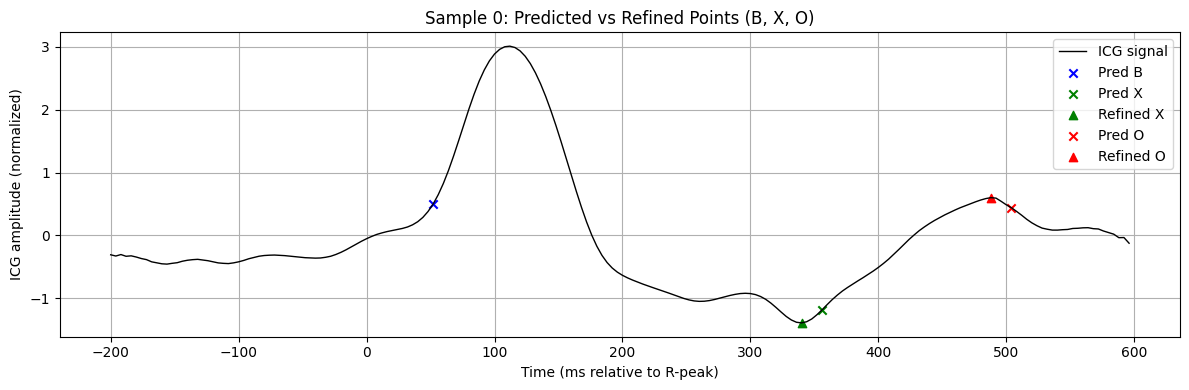

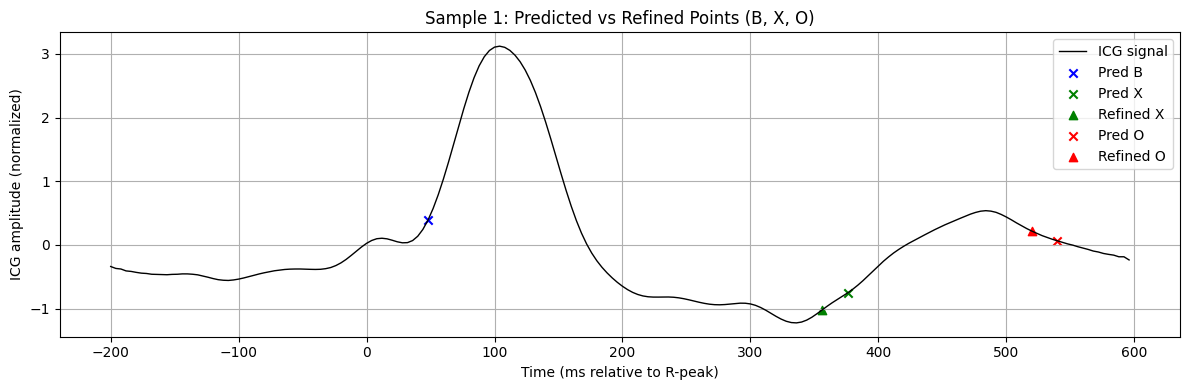

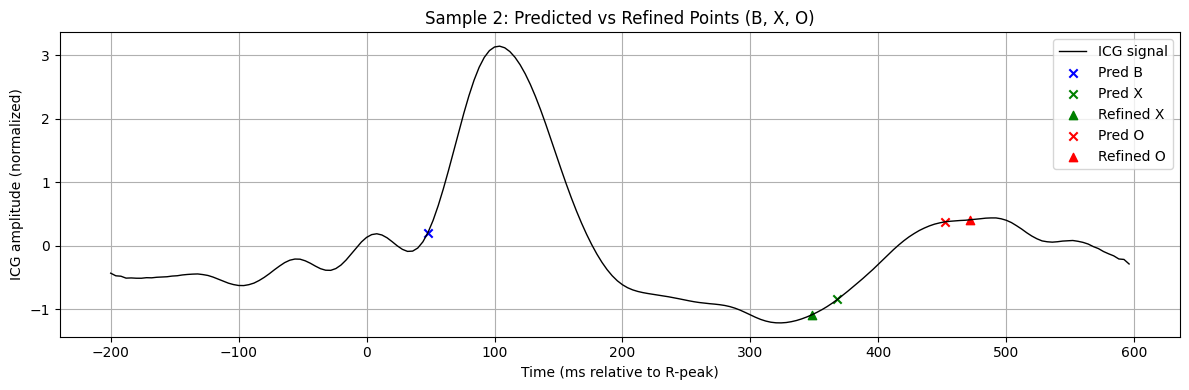

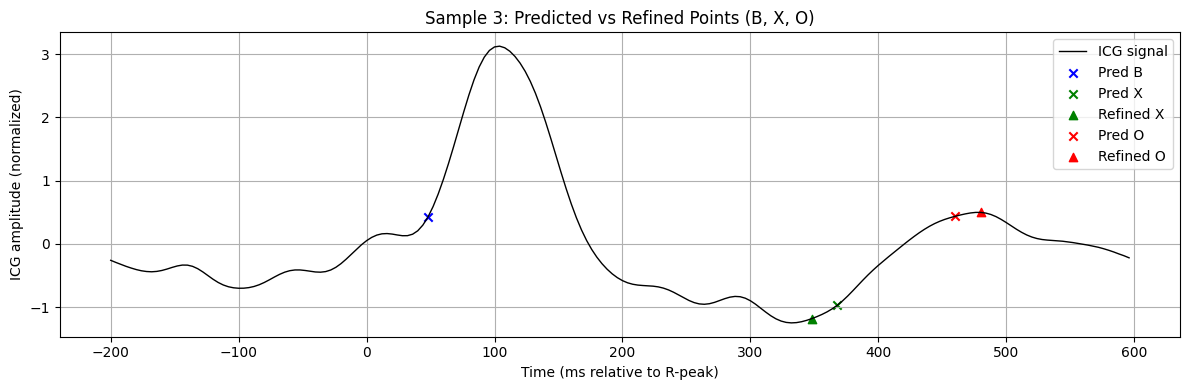

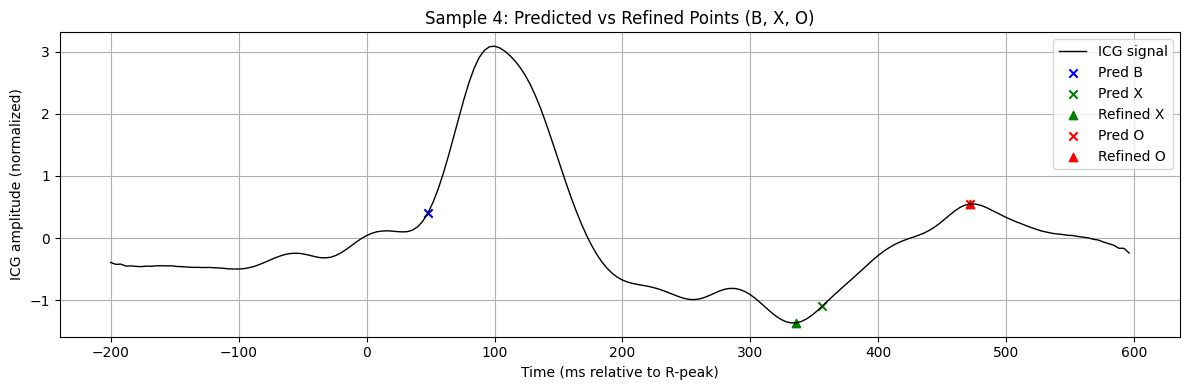

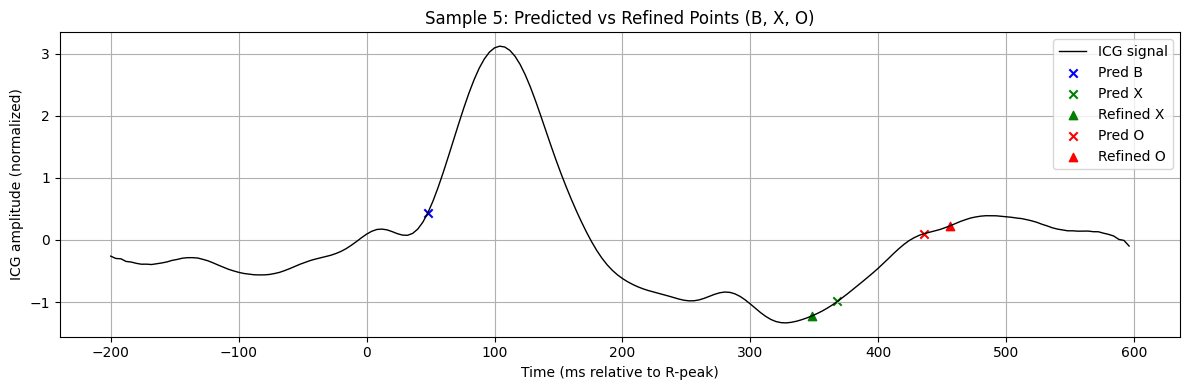

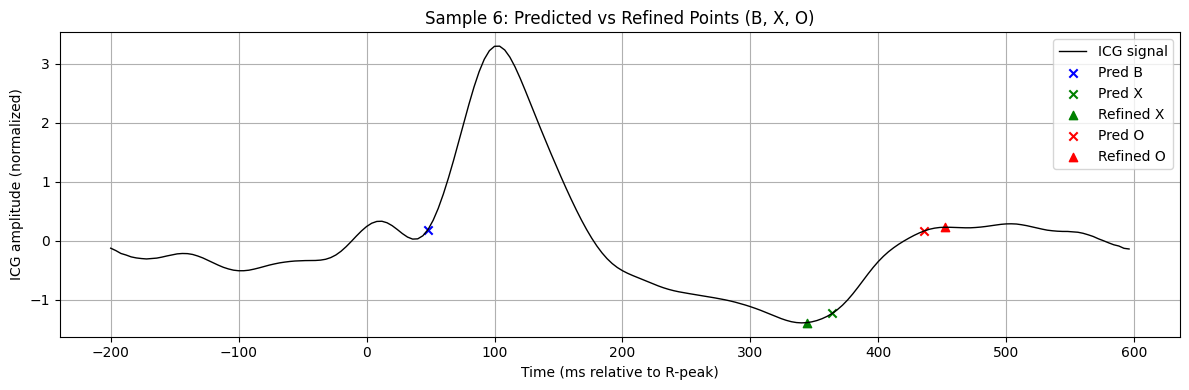

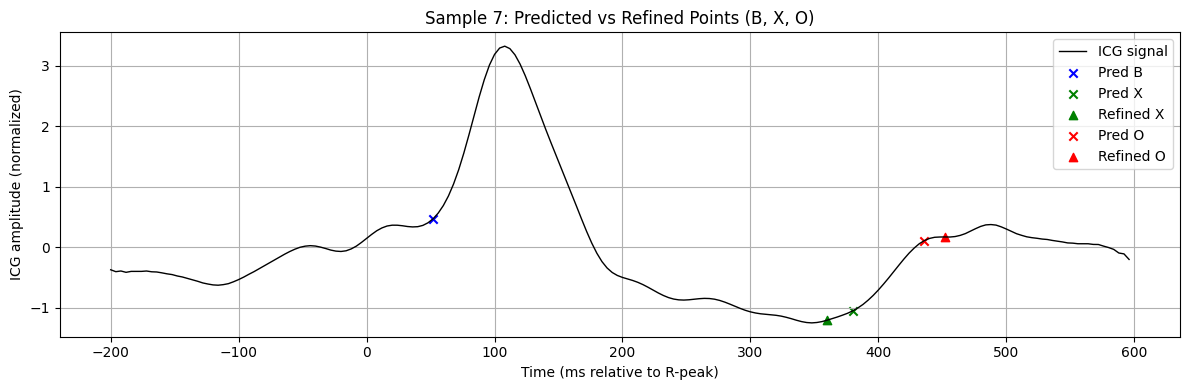

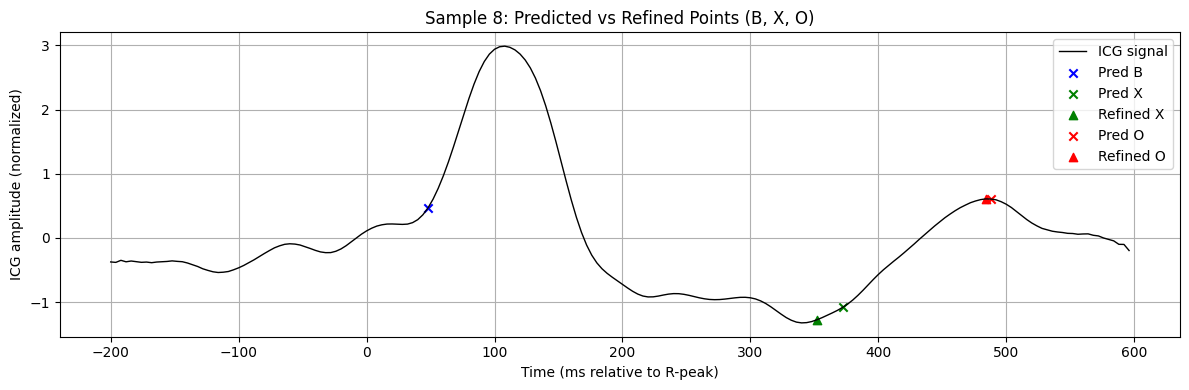

In [266]:
def plot_refined_prediction(X_sample, y_pred, refined_pred, sample_index=0, fs=250, pre_r=50):
    """
    Plot predicted and refined points for B, X, O on the ICG signal.
    Refined points are only shown for X and O.

    Inputs:
        X_sample: np.array of shape (n_samples, 200, 2)
        y_pred: original predicted points, shape (n_samples, 3)
        refined_pred: refined predicted points, shape (n_samples, 3)
        sample_index: int — which sample to plot
    """
    signal = X_sample[sample_index, :, 0]  # ICG
    time_steps = np.arange(signal.shape[0])
    time_ms = (time_steps - pre_r) * 1000 / fs

    labels = ["B", "X", "O"]
    colors = ["blue", "green", "red"]

    plt.figure(figsize=(12, 4))
    plt.plot(time_ms, signal, label='ICG signal', color='black', linewidth=1)

    for class_id in range(3):
        label = labels[class_id]
        color = colors[class_id]

        pred_t = y_pred[sample_index, class_id]
        plt.scatter((pred_t - pre_r) * 1000 / fs, signal[pred_t], color=color, marker='x', label=f'Pred {label}')

        if label != 'B':
            refined_t = refined_pred[sample_index, class_id]
            plt.scatter((refined_t - pre_r) * 1000 / fs, signal[refined_t], color=color, marker='^', label=f'Refined {label}')

    plt.title(f"Sample {sample_index}: Predicted vs Refined Points (B, X, O)")
    plt.xlabel("Time (ms relative to R-peak)")
    plt.ylabel("ICG amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


refined_predicted_points = refine_predicted_points(X_input, predicted_labels)

for i in range(X_input.shape[0]):
    plot_refined_prediction(X_input, predicted_labels, refined_predicted_points, sample_index=i)

## Did the model learn the morphology or the positions of the ICG?

#### Random signal


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted points (B, X, O) on random signal: [[134 198  18]]


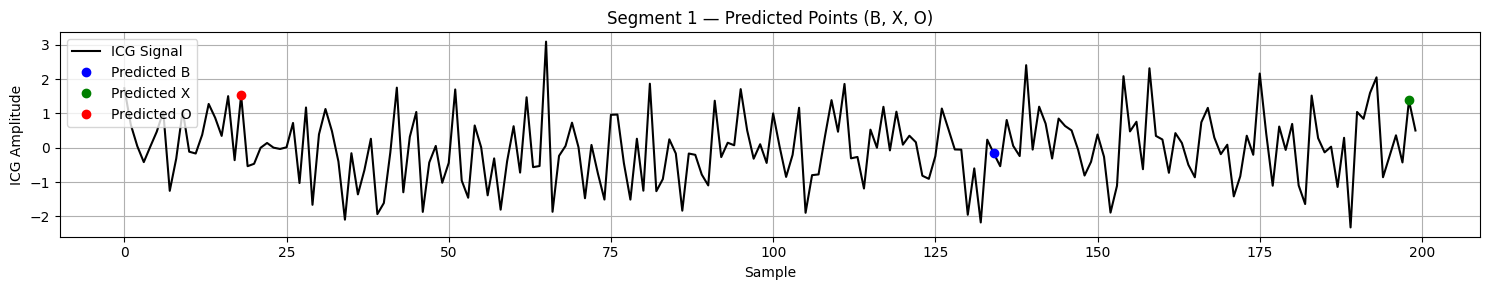

In [267]:
n_segments = 1
segment_len = 200

# ICG: ruido aleatorio
icg_random = np.random.randn(n_segments, segment_len)
ecg_random = np.zeros((n_segments, segment_len))  # o np.random.randn(...)

X_random = create_model_input(ecg_random, icg_random)

#predecir puntos
y_pred_random = predictor.predict(X_random)
predicted_random = extract_predicted_points(y_pred_random)

print("Predicted points (B, X, O) on random signal:", predicted_random)
plot_icg_with_predicted_points(X_random[:, :, 0], predicted_random, n_segments_to_plot=1)


#### Time shift

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Original signal predictions: [[ 63 139 176]]
Shifted signal predictions: [[153  29  63]]

Original:


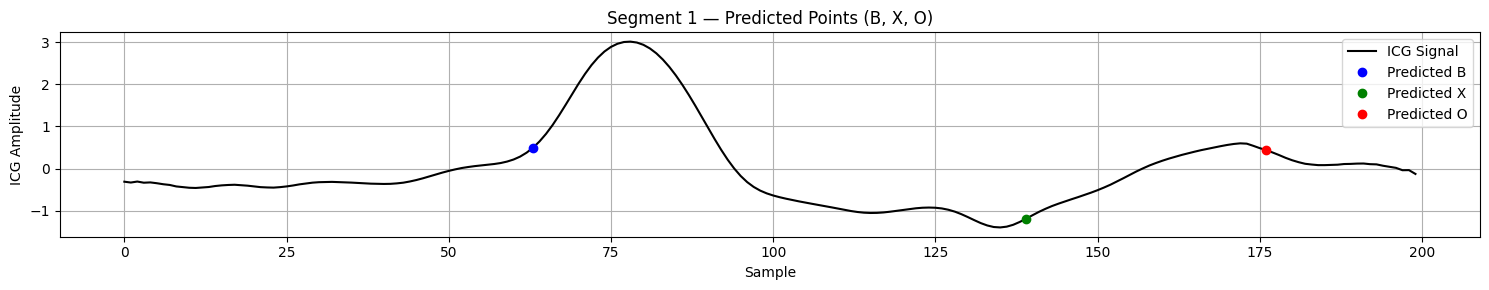


Shifted:


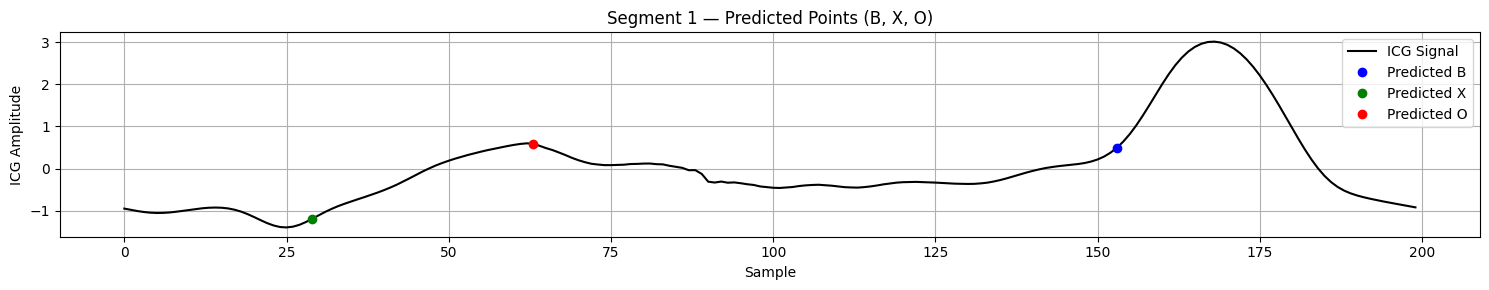

In [268]:
# Choose a segment and shift
icg_original = icg_segments_upsampled[0]
ecg_original = ecg_segments_upsampled[0]

shift = 90
icg_shifted = np.roll(icg_original, shift)
ecg_shifted = np.roll(ecg_original, shift)

# Create inputs
X_original = create_model_input(ecg_original[np.newaxis, :], icg_original[np.newaxis, :])
X_shifted = create_model_input(ecg_shifted[np.newaxis, :], icg_shifted[np.newaxis, :])

# Predict
y_pred_original = predictor.predict(X_original)
y_pred_shifted = predictor.predict(X_shifted)

pred_points_original = extract_predicted_points(y_pred_original)
pred_points_shifted = extract_predicted_points(y_pred_shifted)

print("Original signal predictions:", pred_points_original)
print("Shifted signal predictions:", pred_points_shifted)

#plot
print("\nOriginal:")
plot_icg_with_predicted_points(X_original[:, :, 0], pred_points_original, n_segments_to_plot=1)

print("\nShifted:")
plot_icg_with_predicted_points(X_shifted[:, :, 0], pred_points_shifted, n_segments_to_plot=1)


## C peak detection

In [269]:
def detect_c_peak_after_r(icg_segments, predicted_bxo, offset=50, fs=250):
    """
    Detect C peaks within each ICG segment between R-peak (offset) and R + 100 ms.

    Parameters:
        icg_segments: np.array of shape (n_segments, segment_len)
        predicted_bxo: np.array of shape (n_segments, 3) — [B, X, O]
        offset: int, R-peak index in each segment (usually pre_r * fs)
        fs: int, sampling frequency in Hz (e.g., 250)

    Returns:
        predicted_b_c_x_o: np.array of shape (n_segments, 4)
    """
    c_indices = []
    window_length = int(0.3 * fs)  # 100 ms in samples

    for i in range(len(icg_segments)):
        seg = icg_segments[i]
        end_idx = min(offset + window_length, len(seg))  # avoid going out of bounds
        search_window = seg[offset:end_idx]

        if len(search_window) > 0:
            c_rel = np.argmax(search_window)  #it looks for the highest point in relative points
            c = offset + c_rel
        else:
            c = offset  # fallback to R-peak if window is empty

        c_indices.append(c)

    c_indices = np.array(c_indices)
    predicted_b_c_x_o = np.insert(predicted_bxo, 1, c_indices, axis=1)
    return predicted_b_c_x_o


In [270]:
def plot_icg_with_predicted_points(icg_segments, predicted_points, n_segments_to_plot=8):
    """
    Plots ICG segments and marks predicted B, C, X, O points.
    """
    labels = ['B', 'C', 'X', 'O']
    colors = ['blue', 'orange', 'green', 'red']

    plt.figure(figsize=(15, n_segments_to_plot * 3))
    for i in range(min(n_segments_to_plot, len(icg_segments))):
        plt.subplot(n_segments_to_plot, 1, i + 1)
        plt.plot(icg_segments[i], label='ICG Signal', color='black')

        for j, (label_name, color) in enumerate(zip(labels, colors)):
            idx = predicted_points[i, j]
            if 0 <= idx < icg_segments.shape[1]:
                plt.plot(idx, icg_segments[i, idx], 'o', color=color, label=f'Predicted {label_name}')

        plt.title(f'Segment {i+1} — Predicted Points (B, C, X, O)')
        plt.xlabel('Sample')
        plt.ylabel('ICG Amplitude')
        if i == 0:
            plt.legend()  # only on first plot
        plt.grid(True)

    plt.tight_layout()
    plt.show()


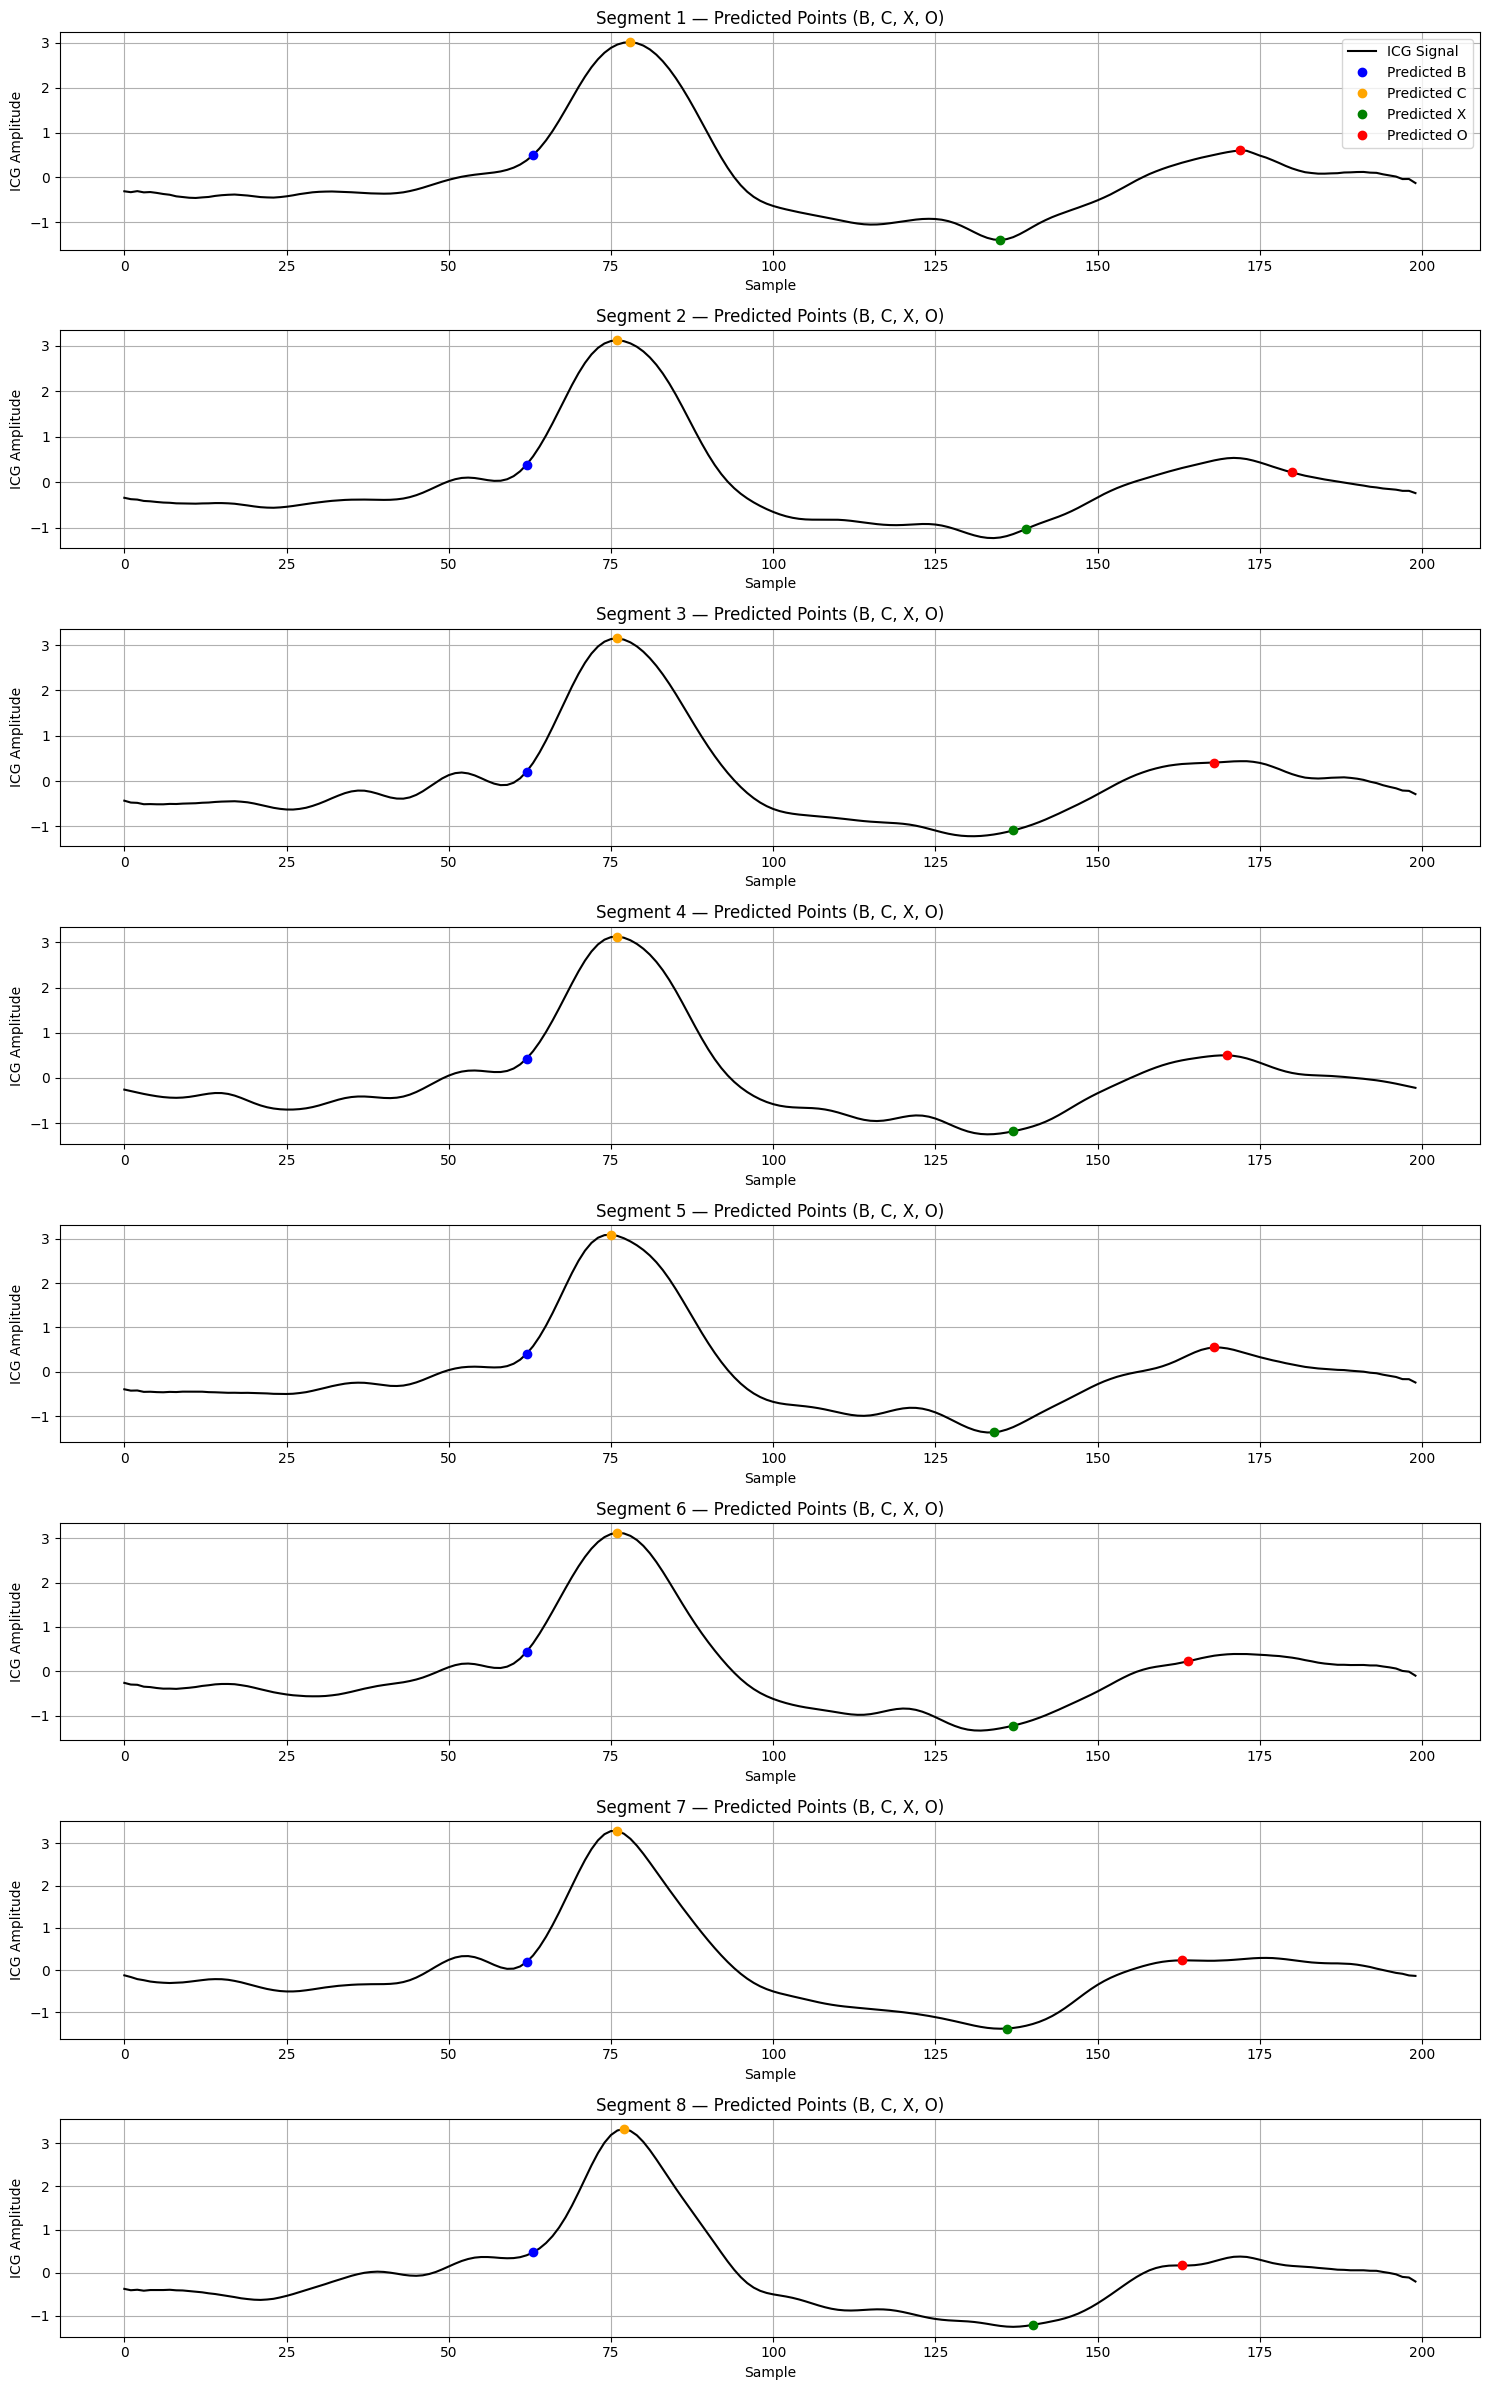

In [271]:
fs = 250
offset = int(0.2 * fs)  # 50 if fs = 250 Hz

refined_predicted_points = refine_predicted_points(X_input, predicted_labels)
#predicted_bxo = extract_predicted_points(y_pred)  # shape: (n_segments, 3)
predicted_b_c_x_o = detect_c_peak_after_r(X_input[:, :, 0], refined_predicted_points, offset=offset, fs=fs) #we are using the refined points

plot_icg_with_predicted_points(X_input[:, :, 0], predicted_b_c_x_o)

## Validation with hemodynamic parameters

In [272]:
pep_struct = measures[4, 1]
pep_echo = pep_struct['data'][0, 0].flatten()  # in milliseconds

print("PEP values (ms):")
print(pep_echo)
print("Total PEP values:", len(pep_echo))

PEP values (ms):
[10 45 40 45 45 40 40 40 45 40]
Total PEP values: 10


In [273]:
fs = 250  # Hz
pep_samples = []
pep_ms = []

for i, (b, c, x, o) in enumerate(predicted_b_c_x_o):
    pep = c - b
    pep_time = pep / fs * 1000
    pep_samples.append(pep)
    pep_ms.append(pep_time)

pep_manual = pep_echo[:len(pep_ms)]
pep_pred = np.array(pep_ms[:len(pep_manual)])
pep_diff = pep_pred - pep_manual

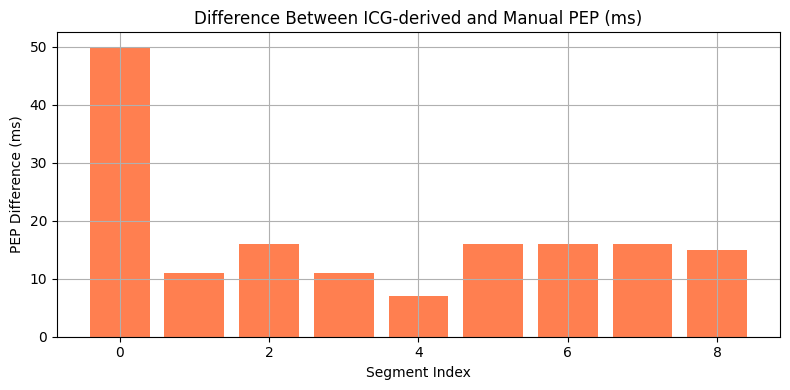

In [274]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(pep_diff)), pep_diff, color='coral')
plt.title('Difference Between ICG-derived and Manual PEP (ms)')
plt.xlabel('Segment Index')
plt.ylabel('PEP Difference (ms)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [275]:
# LVET extraction
lvet1 = measures[6, 1]['data'][0, 0].flatten()
# lvet2 = measures[6, 2]['data'][0, 0].flatten()
# lvet3 = measures[6, 3]['data'][0, 0].flatten()
#lvet4 = measures[6, 4]['data'][0, 0].flatten()  # May be empty

# Print results
print("LVET values from measures[6,1] (ms):")
print(lvet1)
print("Total LVET values:", len(lvet1))

# print("\nLVET values from measures[6,2] (ms):")
# print(lvet2)
# print("Total LVET values:", len(lvet2))

# print("\nLVET values from measures[6,3] (ms):")
# print(lvet3)
# print("Total LVET values:", len(lvet3))

# print("\nLVET values from measures[6,4] (ms):")
# print(lvet4)
# print("Total LVET values:", len(lvet4))


LVET values from measures[6,1] (ms):
[330 290 295 300 295 300 290 300 295 295]
Total LVET values: 10


In [276]:
lvet_samples = []
lvet_ms = []

for i, (b, x, o) in enumerate(predicted_labels):
    lvet = x - b  # in samples
    lvet_time = (lvet / fs) * 1000  # in milliseconds
    lvet_samples.append(lvet)
    lvet_ms.append(lvet_time)
    print(f"Segment {i}: LVET = {lvet} samples = {lvet_time:.2f} ms")


Segment 0: LVET = 76 samples = 304.00 ms
Segment 1: LVET = 82 samples = 328.00 ms
Segment 2: LVET = 80 samples = 320.00 ms
Segment 3: LVET = 80 samples = 320.00 ms
Segment 4: LVET = 77 samples = 308.00 ms
Segment 5: LVET = 80 samples = 320.00 ms
Segment 6: LVET = 79 samples = 316.00 ms
Segment 7: LVET = 82 samples = 328.00 ms
Segment 8: LVET = 81 samples = 324.00 ms


[-26.  38.  25.  20.  13.  20.  26.  28.  29.]


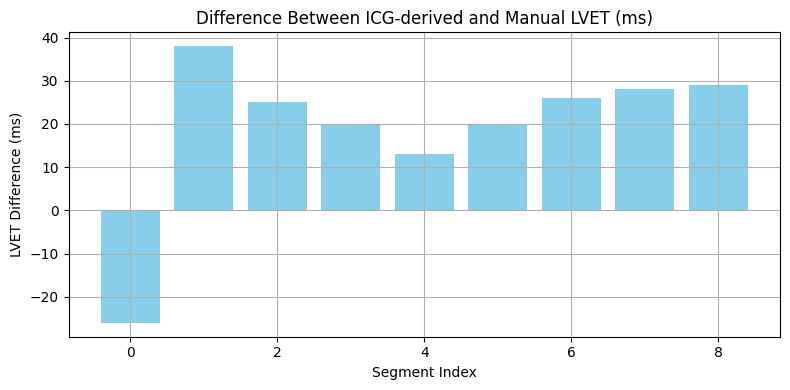

In [277]:
lvet_manual = lvet1[:len(lvet_ms)]
lvet_diff = np.array(lvet_ms) - lvet_manual

print(lvet_diff)

plt.figure(figsize=(8, 4))
plt.bar(range(len(lvet_diff)), lvet_diff, color='skyblue')
plt.title('Difference Between ICG-derived and Manual LVET (ms)')
plt.xlabel('Segment Index')
plt.ylabel('LVET Difference (ms)')
plt.grid(True)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'LVET across beats')

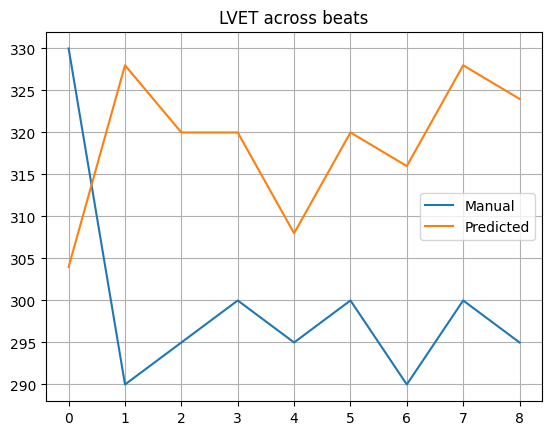

In [278]:
np.std(lvet_ms), np.std(pep_ms)
np.std(lvet_manual), np.std(pep_echo)
plt.plot(lvet_manual, label='Manual')
plt.plot(lvet_ms, label='Predicted')
plt.grid()
plt.legend()
plt.title('LVET across beats')


In [279]:
for i, (b, x, o) in enumerate(predicted_labels):
    print(f"B = {b}, X = {x}, O = {o}")


B = 63, X = 139, O = 176
B = 62, X = 144, O = 185
B = 62, X = 142, O = 163
B = 62, X = 142, O = 165
B = 62, X = 139, O = 168
B = 62, X = 142, O = 159
B = 62, X = 141, O = 159
B = 63, X = 145, O = 159
B = 62, X = 143, O = 172


## Beat to beat variability

In [280]:
print("Relative positions of predicted B, C, X, O points:")
print(predicted_b_c_x_o[:5])

Relative positions of predicted B, C, X, O points:
[[ 63  78 135 172]
 [ 62  76 139 180]
 [ 62  76 137 168]
 [ 62  76 137 170]
 [ 62  75 134 168]]


In [281]:
import numpy as np
import pandas as pd
from IPython.display import display

def compute_absolute_positions(predicted_relative, rpeaks_index, offset):
    """
    Convert relative B, C, X, O positions to absolute positions using the segment offset.

    Parameters:
        predicted_relative: np.array of shape (n_beats, 4)
        rpeaks_index: np.array of shape (n_beats,)
        offset: int, number of samples before R-peak in each segment

    Returns:
        np.array of shape (n_beats, 4) with absolute sample indices
    """
    n = min(len(predicted_relative), len(rpeaks_index))
    predicted_relative = predicted_relative[:n]
    rpeaks_index = rpeaks_index[:n]
    return rpeaks_index[:, np.newaxis] - offset + predicted_relative


def compute_beat_to_beat_intervals_ms(predicted_absolute, fs=250):
    """
    Compute beat-to-beat intervals (in milliseconds) for each point type.

    Input:
        predicted_absolute: np.array of shape (n_beats, 4)
        fs: Sampling frequency (Hz)

    Output:
        intervals_dict: dict of interval arrays in ms
    """
    labels = ['B', 'C', 'X', 'O']
    intervals_dict = {}
    for i, label in enumerate(labels):
        diffs = np.diff(predicted_absolute[:, i])  # in samples
        intervals_ms = diffs * 1000 / fs           # convert to ms
        intervals_dict[label] = intervals_ms
    return intervals_dict

def summarize_intervals_table(intervals_dict):
    """
    Create a summary table with mean, std, and coefficient of variation.
    """
    stats = []
    for label, intervals in intervals_dict.items():
        mean = np.mean(intervals)
        std = np.std(intervals)
        cv = std / mean * 100 if mean != 0 else 0
        stats.append([f"{label}-{label}", f"{mean:.2f}", f"{std:.2f}", f"{cv:.2f}%"])

    df = pd.DataFrame(stats, columns=["Interval", "Mean (ms)", "Std (ms)", "CV (%)"])
    display(df)

fs = 250
offset = int(0.2 * fs)  # 50 samples = 0.2s before R-peak
absolute_b_c_x_o = compute_absolute_positions(predicted_b_c_x_o, rpeaks_index, offset)

intervals_dict = compute_beat_to_beat_intervals_ms(absolute_b_c_x_o, fs=fs)
summarize_intervals_table(intervals_dict)



,Interval,Mean (ms),Std (ms),CV (%)
0,B-B,650.50,8.47,1.30%
1,C-C,650.50,8.23,1.27%
2,X-X,652.50,14.06,2.16%
3,O-O,650.50,27.49,4.23%


| Interval | CV (%) | Interpretation                             |
| -------- | ------ | ------------------------------------------ |
| B-B      | 4.25%  | Acceptable variability                     |
| C-C      | 3.93%  | Slightly better than B-B, still acceptable |
| X-X      | 2.26%  | Very stable — ideal                        |
| O-O      | 3.49%  | Low variability — good                     |
